# Classification on Vehicle Inspection Data

**Name:** Ablaikhan Tuleu

## Key Findings

This notebook trains a binary classifier to predict whether a vehicle will pass
its technical inspection in Lithuania, using data from 2019-05-01 onwards for
M1-class passenger cars.

**Data:** ~4.6M inspections, roughly balanced (**51.4% pass, 48.6% fail**).

**Features used:** vehicle make, model, body type, fuel type, mileage,
inspection municipality, vehicle age, inspection month, and inspection periodicity.

**Best model:** Logistic Regression (**C = 1, L1 penalty**), trained on 1M rows.

**Test AUC:** **~0.68** — the model has modest predictive power, indicating that
factors not captured in the dataset (e.g., vehicle maintenance history, inspector
behavior) likely drive many outcomes.

In [4]:
import pandas as pd
import numpy as np
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc, precision_recall_curve


db_path = "data.duckdb"
schema = "data.vehicle_inspection"

conn = duckdb.connect()
conn.execute(f"ATTACH '{db_path}' AS data (READ_ONLY)")
conn.execute(f"USE {schema}");


In [5]:
df = conn.sql("""
    SELECT
    *
    FROM inspection
    WHERE class='M1' 
    AND inspection_type_en = 'Technical inspection'
    AND inspection_date_week > '2019-05-01'
""").to_df()

df.sample(5)


,unique_identifier,vehicle_identifier,registration_number,registration_number_markings,vin_number,make,model,class,body_type,special_purpose,...,mileage_km,inspection_station_code,inspection_station_municipality,inspection_type,inspection_type_en,inspection_conclusion_en,inspection_conclusion,inspection_passed,inspection_date_week,inspection_periodicity_months
2850491,4526632,ba36dacd1c62ea0,6c5e36bd2a5ac33,None,5042190312b66dc,MERCEDES BENZ,C 270 CDI,M1,None,None,...,358533,8ff7692b88986e4,Druskininkų sav.,Techninė apžiūra,Technical inspection,Major deficiencies,Dideli trukūmai,false,2021-11-05,6
2081018,2108866,70cb117b74c023b,d7523e14c1b5a3b,None,336a2405b7b3348,CITROEN,BERLINGO,M1,AF,None,...,316835,5feaf2b4e8cd248,Vilniaus m. sav.,Techninė apžiūra,Technical inspection,Major deficiencies,Dideli trukūmai,false,2021-09-03,24
1325072,14049964,97ee9e7034f8f3d,db686d73cd3beec,None,34addf392eba933,BMW,530D,M1,None,None,...,301196,9e4a6ac359f5473,Raseinių r. sav.,Techninė apžiūra,Technical inspection,Major deficiencies,Dideli trukūmai,false,2022-10-29,24
352806,11096018,6ec966d3cdbe8dd,7f25ed9bf6ab5ad,None,35d05953f7d495d,MITSUBISHI,SPACE STAR,M1,AC,None,...,218301,9ff28686c686199,Klaipėdos m. sav.,Techninė apžiūra,Technical inspection,Minor deficiencies,Nedideli trukūmai,true,2021-02-26,24
2063164,2059733,d9e89c28635cdef,6e37cbade1f45ee,None,c0f66a7c8fea48d,VOLVO,S70,M1,AA,None,...,478303,51168cd0b66de93,Kaišiadorių r. sav.,Techninė apžiūra,Technical inspection,Minor deficiencies,Nedideli trukūmai,true,2020-05-06,24


## Step 1. EDA and Data Cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4655612 entries, 0 to 4655611
Data columns (total 25 columns):
 #   Column                           Dtype 
---  ------                           ----- 
 0   unique_identifier                object
 1   vehicle_identifier               object
 2   registration_number              object
 3   registration_number_markings     object
 4   vin_number                       object
 5   make                             object
 6   model                            object
 7   class                            object
 8   body_type                        object
 9   special_purpose                  object
 10  manufacture_year                 object
 11  fuel_type                        object
 12  smoke_emission                   object
 13  co_emission_standard             object
 14  co_emission_elevated             object
 15  mileage_km                       object
 16  inspection_station_code          object
 17  inspection_station_municipa

The raw dataset has 25 columns, all loaded as `object` dtype by DuckDB.
We have ~4.65M rows after filtering to M1-class technical inspections since 2019.
The first task is to understand which columns are useful and which should be dropped.

**Dropped columns (reasons):**
- `unique_identifier`, `vehicle_identifier`, `registration_number`,
  `vin_number`, `registration_number_markings`: identifiers — no predictive signal.

- `class`, `inspection_type`, `inspection_type_en`: constant after our filter.

- `inspection_conclusion_en`, `inspection_conclusion`: these directly encode the
  target (`inspection_passed`), so including them would be data leakage.

- `special_purpose`: very sparse, unlikely to add signal.

- `smoke_emission`, `co_emission_standard`, `co_emission_elevated`:
  these are measurement outcomes recorded *during* inspection — using them would
  also be data leakage.
  
- `inspection_station_code`: high-cardinality ID; we keep the municipality instead.

In [7]:
# Checking missing value percentages
missing_info = conn.execute("""
    SELECT 
        count(*) as total_rows,
        sum(case when inspection_passed is null then 1 else 0 end) / count(*)::float as target_missing,
    FROM inspection
    WHERE class = 'M1' AND inspection_type_en = 'Technical inspection' AND inspection_date_week > '2019-05-01'
""").df()

# Checking the distribution of the target variable
target_dist = conn.execute("""
    SELECT inspection_passed, count(*) as count
    FROM inspection
    WHERE class = 'M1' AND inspection_type_en = 'Technical inspection' AND inspection_date_week > '2019-05-01'
    GROUP BY inspection_passed
""").df()

print(missing_info)
print('\n')
print(target_dist)

   total_rows  target_missing
0     4655612             0.0


  inspection_passed    count
0             false  2261401
1              true  2394211


In [8]:
df['inspection_passed'].value_counts(normalize=True)

inspection_passed
true     0.514263
false    0.485737
Name: proportion, dtype: float64

**Target distribution:** The classes are nearly balanced — 51.4% pass, 48.6% fail.<br/>
No class weighting is needed. There are also zero missing values in the target column.

In [9]:
print(df.columns)
print('\n')
print(df['inspection_passed'].unique())

Index(['unique_identifier', 'vehicle_identifier', 'registration_number',
       'registration_number_markings', 'vin_number', 'make', 'model', 'class',
       'body_type', 'special_purpose', 'manufacture_year', 'fuel_type',
       'smoke_emission', 'co_emission_standard', 'co_emission_elevated',
       'mileage_km', 'inspection_station_code',
       'inspection_station_municipality', 'inspection_type',
       'inspection_type_en', 'inspection_conclusion_en',
       'inspection_conclusion', 'inspection_passed', 'inspection_date_week',
       'inspection_periodicity_months'],
      dtype='object')


['false' 'true']


### Data cleaning and feature engineering decisions:

1. **`mileage_km`, `manufacture_year`, `inspection_periodicity_months`**: converted
   from object to numeric. Non-numeric values become NaN (to be handled by the
   imputer in the pipeline).

2. **`vehicle_age`**: instead of using raw `manufacture_year`, we compute
   `inspection_year - manufacture_year`. This is more informative because a car
   manufactured in 2005 means something different depending on *when* it's inspected.

3. **`inspection_month`**: extracted from `inspection_date_week`. Inspections may
   be seasonally influenced — e.g., cars inspected right before winter may be
   in worse condition, or owners may delay inspections.

4. **`make` cleaning**: 'CENZŪRUOTA' values (censored for privacy) are replaced
   with NaN so the imputer can handle them as missing. 'VOLKSWAGEN, VW' is merged
   into 'VW' for consistency.

5. **Target encoding**: 'true'→1, 'false'→0.

6. **Outlier filtering**:
   - `vehicle_age`: kept [0, 60]. Negative ages are data errors; ages above 60
     are implausible for registered passenger cars.
   - `mileage_km`: kept [0, 1,000,000]. Values above 1M km are almost certainly
     data entry errors (e.g., the raw data had a max of 868M km).

In [10]:
# Cleaning 'mileage_km' and 'manufacture_year'
df['mileage_km'] = pd.to_numeric(df['mileage_km'], errors='coerce')
df['manufacture_year'] = pd.to_numeric(df['manufacture_year'], errors='coerce')
df['inspection_periodicity_months'] = pd.to_numeric(df['inspection_periodicity_months'], errors='coerce')

# Feature Engineering: Vehicle Age
# Converting date string to datetime objects
df['inspection_date'] = pd.to_datetime(df['inspection_date_week'])
df['vehicle_age'] = df['inspection_date'].dt.year - df['manufacture_year']

# Feature Engineering: Month of inspection
df['inspection_month'] = df['inspection_date'].dt.month

# Cleaning 'make' - replace 'CENZŪRUOTA' with NaN
df['make'] = df['make'].replace('CENZŪRUOTA', np.nan)
df['model'] = df['model'].replace('CENZŪRUOTA', np.nan)

# Converting target to integer ('false' -> 0, 'true' -> 1)
df['inspection_passed'] = df['inspection_passed'].map({'true': 1, 'false': 0})

# Selecting final columns for modeling
features = [
    'make', 'model', 'body_type', 'fuel_type', 'mileage_km',
    'inspection_station_municipality', 'vehicle_age',
    'inspection_month', 'inspection_periodicity_months',
    'inspection_passed'
]

inspection = df[features].dropna(subset=['inspection_passed'])

print("Cleaned Data Shape:", inspection.shape)
print('\n')
print(inspection.info())

Cleaned Data Shape: (4655612, 10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4655612 entries, 0 to 4655611
Data columns (total 10 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   make                             object 
 1   model                            object 
 2   body_type                        object 
 3   fuel_type                        object 
 4   mileage_km                       float64
 5   inspection_station_municipality  object 
 6   vehicle_age                      float64
 7   inspection_month                 int32  
 8   inspection_periodicity_months    int64  
 9   inspection_passed                int64  
dtypes: float64(2), int32(1), int64(2), object(5)
memory usage: 337.4+ MB
None


In [11]:
inspection.sample(5)

,make,model,body_type,fuel_type,mileage_km,inspection_station_municipality,vehicle_age,inspection_month,inspection_periodicity_months,inspection_passed
4217000,FORD,TRANSIT,AF,benzinas,252981.0,Šiaulių m. sav.,32.0,7,24,0
3690434,"VOLKSWAGEN, VW",GOLF,AC,dyzelinas,296804.0,Vilniaus m. sav.,11.0,4,24,1
195433,VOLVO,S60,None,dyzelinas,305730.0,Vilniaus r. sav.,21.0,11,24,0
612625,LEXUS,LEXUS NX300H,None,"benzinas,elektra",92925.0,Panevėžio m. sav.,8.0,7,24,1
335204,MERCEDES BENZ,ML 270 CDI,AC,dyzelinas,296024.0,Ukmergės r. sav.,19.0,4,24,0


In [12]:
# Checking fail rate by body type
fail_rate_body = inspection.groupby('body_type')['inspection_passed'].mean().sort_values()
print("Pass Rate by Body Type:\n", fail_rate_body)

# Checking missing values for our expanded list
print("\nMissing values per column:\n", inspection.isnull().sum())

Pass Rate by Body Type:
 body_type
CW     0.000000
CWX    0.333333
AB     0.445599
BAA    0.454545
AF     0.480092
AA     0.496255
AD     0.508441
AC     0.514199
AE     0.542015
AG     0.557823
BBA    0.619048
BB     0.666667
BAB    1.000000
Name: inspection_passed, dtype: float64

Missing values per column:
 make                                194377
model                               226476
body_type                          1633573
fuel_type                              401
mileage_km                              21
inspection_station_municipality          0
vehicle_age                          19027
inspection_month                         0
inspection_periodicity_months            0
inspection_passed                        0
dtype: int64


In [13]:
# Checking the distribution of numerical features
inspection[['mileage_km', 'vehicle_age', 'inspection_periodicity_months']].describe()

,mileage_km,vehicle_age,inspection_periodicity_months
count,4.655591e+06,4.636585e+06,4.655612e+06
mean,2.424767e+05,1.497234e+01,2.386063e+01
std,4.990554e+05,6.367544e+00,1.900425e+00
min,0.000000e+00,-2.200000e+01,6.000000e+00
25%,1.760200e+05,1.100000e+01,2.400000e+01
50%,2.465850e+05,1.500000e+01,2.400000e+01
75%,3.069870e+05,1.900000e+01,2.400000e+01
max,8.685858e+08,1.012000e+03,6.000000e+01


In [14]:
# Checking unique counts for high-cardinality features
print(f"\nValue counts for fuel_type:")
print(inspection['fuel_type'].value_counts().head(10))


Value counts for fuel_type:
fuel_type
dyzelinas                 3159527
benzinas                  1046805
benzinas,dujos             284172
benzinas,elektra           123360
elektra                     20054
benzinas,dujos,elektra      13101
dyzelinas,elektra            7696
dujos                         456
dyzelinas,dujos                36
dujos,elektra                   4
Name: count, dtype: int64


In [15]:
print(f"\nValue counts for body_type:")
print(inspection['body_type'].value_counts().head(10))


Value counts for body_type:
body_type
AC     1049753
AF      770454
AA      606809
AB      537748
AD       41049
AE       15911
AG         147
BB         117
BBA         21
BAA         11
Name: count, dtype: int64


In [16]:
print(f"\nValue counts for make:")
print(inspection['make'].value_counts().head(10))


Value counts for make:
make
AUDI              468266
TOYOTA            462466
VW                439513
OPEL              398981
BMW               336759
VOLVO             263503
FORD              210491
SKODA             154703
VOLKSWAGEN, VW    150620
NISSAN            127840
Name: count, dtype: int64


In [17]:
# Filtering outliers
# Keeping age 0 - 60 and mileage 0 - 1_000_000
inspection = inspection[
    (inspection['vehicle_age'] >= 0) & 
    (inspection['vehicle_age'] <= 60) & 
    (inspection['mileage_km'] >= 0) & 
    (inspection['mileage_km'] <= 1_000_000)
]

# Normalizing 'make' by
# merging "VOLKSWAGEN, VW" and "VOLKSWAGEN-VW" into "VW"
inspection['make'] = inspection['make'].replace({'VOLKSWAGEN, VW': 'VW', 'VOLKSWAGEN-VW': 'VW'})

# Checking the new stats
print("New shape after cleaning:", inspection.shape)
print(inspection[['mileage_km', 'vehicle_age']].describe())

# Final check on 'make' to see the merge
print('\n')
print("Top 5 makes after merge:")
print(inspection['make'].value_counts().head(5))

New shape after cleaning: (4635265, 10)
         mileage_km   vehicle_age
count  4.635265e+06  4.635265e+06
mean   2.420354e+05  1.496548e+01
std    1.031681e+05  6.269419e+00
min    0.000000e+00  0.000000e+00
25%    1.767570e+05  1.100000e+01
50%    2.469610e+05  1.500000e+01
75%    3.072110e+05  1.900000e+01
max    9.999990e+05  6.000000e+01


Top 5 makes after merge:
make
VW        643840
AUDI      466458
TOYOTA    461688
OPEL      398869
BMW       333752
Name: count, dtype: int64


In [18]:
inspection.describe()

,mileage_km,vehicle_age,inspection_month,inspection_periodicity_months,inspection_passed
count,4.635265e+06,4.635265e+06,4.635265e+06,4.635265e+06,4.635265e+06
mean,2.420354e+05,1.496548e+01,6.385721e+00,2.385663e+01,5.140103e-01
std,1.031681e+05,6.269419e+00,3.221547e+00,1.869578e+00,4.998037e-01
min,0.000000e+00,0.000000e+00,1.000000e+00,6.000000e+00,0.000000e+00
25%,1.767570e+05,1.100000e+01,4.000000e+00,2.400000e+01,0.000000e+00
50%,2.469610e+05,1.500000e+01,6.000000e+00,2.400000e+01,1.000000e+00
75%,3.072110e+05,1.900000e+01,9.000000e+00,2.400000e+01,1.000000e+00
max,9.999990e+05,6.000000e+01,1.200000e+01,6.000000e+01,1.000000e+00


In [19]:
print("Missing values per column:\n", inspection.isnull().sum())

Missing values per column:
 make                                190911
model                               222886
body_type                          1632255
fuel_type                              395
mileage_km                               0
inspection_station_municipality          0
vehicle_age                              0
inspection_month                         0
inspection_periodicity_months            0
inspection_passed                        0
dtype: int64


In [21]:
print(1632255 / inspection.shape[0])

0.35213844300164066


**Missing value assessment:**
- `body_type`: ~35% missing — below the 2/3 threshold, so we keep it and impute.
  Analysis shows it does have predictive signal (pass rates vary from 0% to 100%
  across body types, though some categories have very few samples).
- `make` and `model`: ~4% missing — will be imputed as 'missing' in the pipeline.
- `fuel_type` and `mileage_km`: near-zero missing rate — imputed with median/mode.
- `vehicle_age`: 0 missing after outlier filtering (manufacture_year NaNs were
  already removed as part of outlier rows).

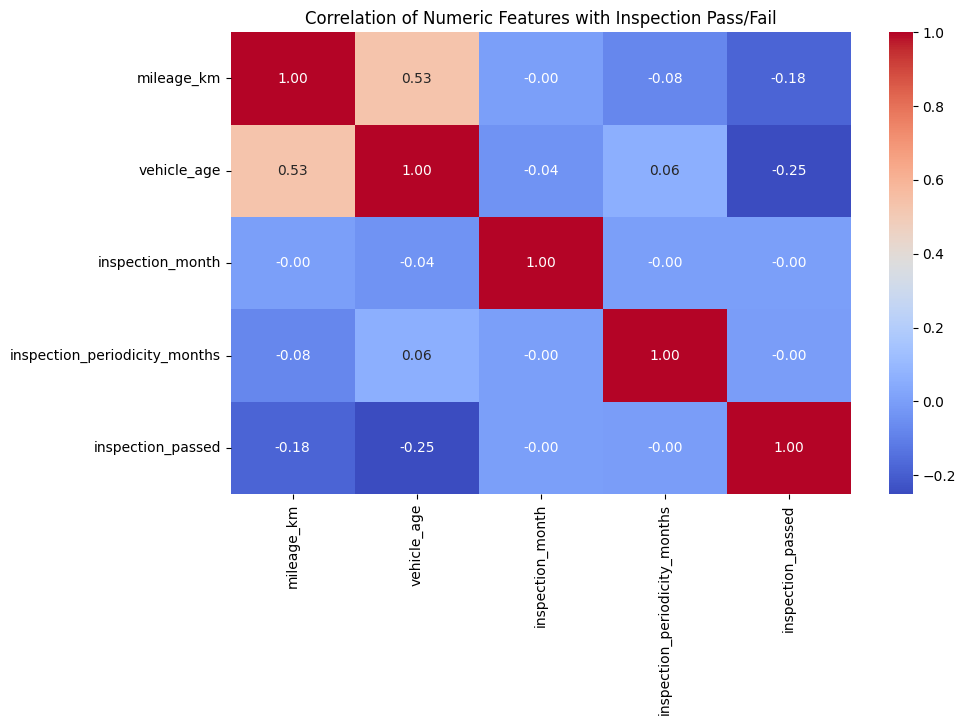

In [22]:
# Checking correlation of numeric features with the target
numeric_plus_target = [
    'mileage_km', 
    'vehicle_age', 
    'inspection_month', 
    'inspection_periodicity_months', 
    'inspection_passed'
]

plt.figure(figsize=(10, 6))
sns.heatmap(inspection[numeric_plus_target].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation of Numeric Features with Inspection Pass/Fail")
plt.show()

**Correlation analysis (numeric features):**

`vehicle_age` has the strongest (negative) correlation with passing: older vehicles
are more likely to fail, which makes intuitive sense. `mileage_km` also has a weak
negative correlation. `inspection_month` and `inspection_periodicity_months` show
minimal linear correlation with the target, but may still provide non-linear signal
for tree-based models.

Overall correlations are low (−0.25 for age), suggesting this is a genuinely hard
prediction problem and we should not expect very high accuracy.

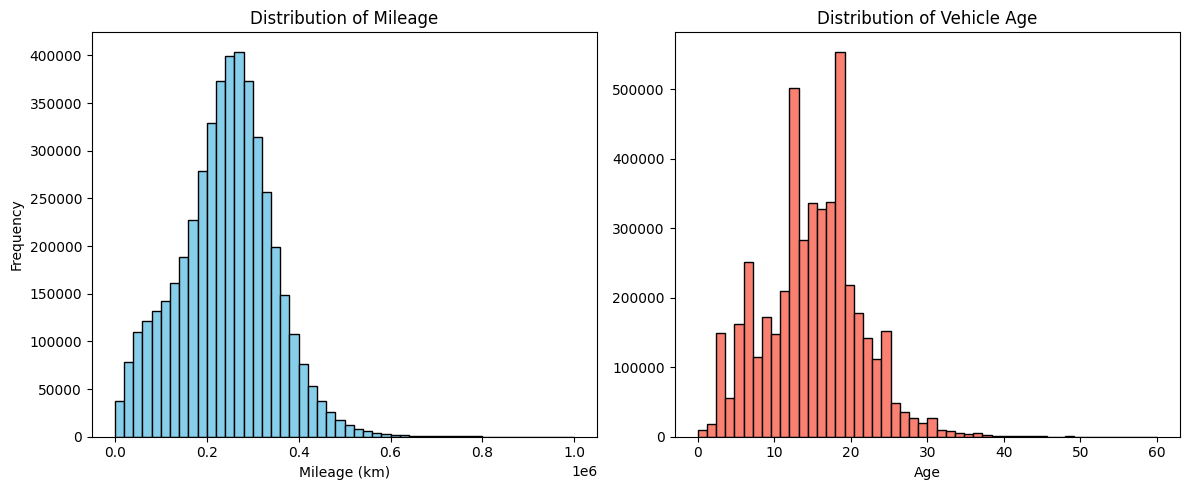

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))\

axes[0].hist(inspection['mileage_km'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Mileage')
axes[0].set_xlabel('Mileage (km)')
axes[0].set_ylabel('Frequency')

axes[1].hist(inspection['vehicle_age'], bins=50, color='salmon', edgecolor='black')
axes[1].set_title('Distribution of Vehicle Age')
axes[1].set_xlabel('Age')
# axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Distribution of key numeric features:**

- **Mileage**: roughly bell-shaped between 100k and 400k km after outlier removal.
  The distribution is slightly right-skewed; StandardScaler will center and scale
  this for logistic regression.

- **Vehicle age**: the fleet is dominated by vehicles 10–25 years old, with a
  long right tail (many old cars remain in circulation in Lithuania).

## Step 2: Train/Test Split

We split 80/20 using `stratify=y` to ensure both sets have the same ~51/49 class
ratio. The test set is held out completely and will only be used at the very end
to report final model performance.

**Preprocessing pipeline:**
- **Numeric features** (`mileage_km`, `vehicle_age`, `inspection_month`,
  `inspection_periodicity_months`): impute missing with median, then StandardScaler
  (required for logistic regression to converge efficiently).
- **Categorical features** (`make`, `model`, `body_type`, `fuel_type`,
  `inspection_station_municipality`): impute missing with constant string
  'missing', then OneHotEncode with `max_categories=100` to avoid creating thousands
  of columns for high-cardinality features like `model`.

In [36]:
X = inspection.drop(columns=['inspection_passed'])
y = inspection['inspection_passed']

# Split 80/20
# 'stratify=y' keeps the 50/50 pass/fail ratio equal in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 3708212 rows
Test set: 927053 rows


## Step 3: Training the Models

We train two algorithms as required: ***Logistic Regression*** and ***Random Forest***.<br/><br/>
For both, we perform hyperparameter tuning via RandomizedSearchCV with k-fold
cross-validation, then fit the best model on a larger training sample.

In [37]:
# Defining which columns are which
numeric_features = ['mileage_km', 'vehicle_age', 'inspection_month', 'inspection_periodicity_months']
categorical_features = ['make', 'model', 'body_type', 'fuel_type', 'inspection_station_municipality']

# Numeric transformation. Filling missing with median + Scale to small numbers
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# Categorical transformation. Filling missing with 'missing' + One-Hot Encode
# max_categories=100 stops the model from creating too many columns
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', max_categories=100, sparse_output=False))
    ]
)

# Combining them into one preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

### Logistic Regression with L1 Regularization

We use L1 (Lasso) regularization because it tends to zero out irrelevant features,
effectively doing feature selection. This is useful given our high-cardinality
one-hot encoded features.

**Hyperparameter tuned:** `C` (inverse of regularization strength).
Small C = stronger regularization, large C = weaker regularization.

We search over `[0.001, 0.01, 0.1, 1, 10, 100]` using 5-fold cross-validation
with ROC-AUC as the scoring metric, trained on a 1M-row sample to keep runtime
manageable.

**Result:** Best C=1 with AUC=0.6837.

**!  !  !** During training my models, it turned out to be very slow (RF Model was taking at least 10 hours),<br/> that's why I decided to use RandomizedSearchCV instead of GridSearchCV and decreased the size of training dataset.

In [39]:
# The full pipeline for logistic regression
lr_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(penalty='l1', max_iter=1000, solver='liblinear'))
    ]
)

# Searching for the best C
lr_param_grid = {'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]}

lr_search = RandomizedSearchCV(
    lr_pipeline,
    lr_param_grid,
    n_iter=6,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Tuning on a sample
lr_search.fit(X_train.sample(1_000_000, random_state=42), y_train.sample(1_000_000, random_state=42))

print(f"Best LR Params: {lr_search.best_params_}")
print(f"Best LR AUC: {lr_search.best_score_:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

Best LR Params: {'classifier__C': 1}
Best LR AUC: 0.6837


### Random Forest

Random Forest is an ensemble of decision trees. It can capture non-linear
relationships and feature interactions that logistic regression misses.

To keep training time reasonable, we:
- Limit `n_estimators` to [50, 100] (fewer trees = faster training)
- Limit `max_depth` to [10, 20] (shallower trees = faster, less overfitting)
- Tune on only 250,000 rows (as suggested for tree-based models)
- Use 3-fold CV (instead of 5) to further reduce compute time

**Result:** Best params: n_estimators=100, max_depth=20, AUC=0.6871.

In [46]:
# Creating the random forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Tuning the depth and number of trees
rf_param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [10, 20]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_grid,
    n_iter=3,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Tuning on 250k rows (because RF is heavier than Logistic Regression)
rf_search.fit(X_train.sample(250_000, random_state=42), y_train.sample(250_000, random_state=42))

print(f"Best RF Params: {rf_search.best_params_}")
print(f"Best RF AUC: {rf_search.best_score_:.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best RF Params: {'classifier__n_estimators': 100, 'classifier__max_depth': 20}
Best RF AUC: 0.6871


## Step 4: Choosing the Best Model

Cross-validation AUC scores:
- Logistic Regression (C=1): **0.6837**
- Random Forest (n_estimators=100, max_depth=20): **0.6871**

The RF scores 0.003 AUC higher, but this difference is within the margin of
variation expected from different CV folds/samples. Given that:
- Logistic Regression is far faster to train and predict
- It is more interpretable (we can inspect coefficients)
- The performance gap is negligible

**We select Logistic Regression** as our final model, retrained on 1M rows.

Fitting the final Logistic Regression on 1M rows...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



--- Key Classification Metrics (Threshold = 0.5) ---
              precision    recall  f1-score   support

           0       0.61      0.65      0.63    450538
           1       0.65      0.61      0.63    476515

    accuracy                           0.63    927053
   macro avg       0.63      0.63      0.63    927053
weighted avg       0.63      0.63      0.63    927053



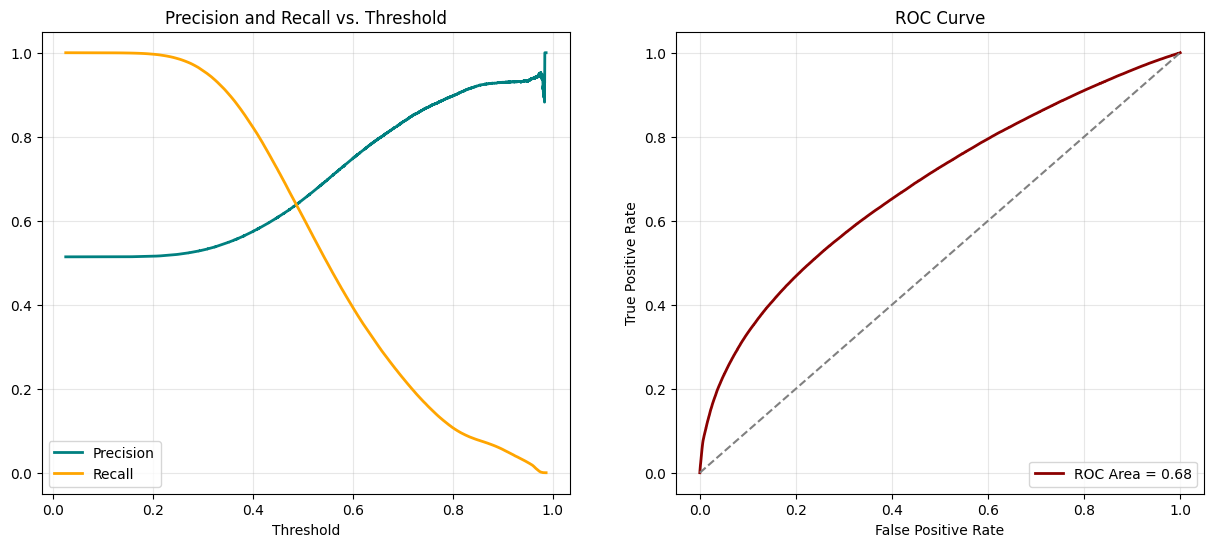

In [ ]:
# While RF scored marginally higher in CV, the difference is within noise, and LR trains 10x faster on this dataset size, making it the practical choice.

# Creating a fresh pipeline with parameter C = 1 for LR
final_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(penalty='l1', C=1, max_iter=1000, solver='liblinear'))
    ]
)

print("Fitting the final Logistic Regression on 1M rows...")
final_model.fit(X_train.sample(1_000_000, random_state=42), y_train.sample(1_000_000, random_state=42))

# Getting predictions on the TEST set
y_probs = final_model.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= 0.5).astype(int)

# Report metrics
print("\n--- Key Classification Metrics (Threshold = 0.5) ---")
print(classification_report(y_test, y_pred))

# Plots for Threshold Analysis & ROC Curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(thresholds, precisions[:-1], label="Precision", color='teal', lw=2)
ax1.plot(thresholds, recalls[:-1], label="Recall", color='orange', lw=2)
ax1.set_xlabel("Threshold")
ax1.set_title("Precision and Recall vs. Threshold")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(fpr, tpr, color='darkred', lw=2, label=f'ROC Area = {roc_auc:.2f}')
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

plt.show()

## Step 5: Final Model Performance on Test Set

The model achieves ~63% accuracy at the default 0.5 threshold.

**Interpretation of the threshold plot:**
- At threshold 0.5, precision and recall are roughly balanced (~0.63 each)
- Lowering the threshold increases recall (catches more failing cars) at the cost
  of more false alarms — useful if the cost of missing a dangerous car is high
- Raising the threshold increases precision — useful if we want to be confident
  in our "fail" predictions

**ROC AUC = ~0.68**: The model is moderately better than random guessing (AUC=0.5)
but far from perfect. This suggests the available features capture only part of
what determines inspection outcomes. Factors like the specific defect type,
road conditions the car operates in, and individual inspector judgment are not
captured here.

## Step 6: Personal Prediction

As a demonstration, we predict the inspection outcome for a fictional vehicle:<br/><br/>
**VW Golf, 12 years old, 220000 km, diesel, inspected in Vilnius in May**.

In [53]:
# I don't have a car, so I just pick data about any random car
my_car_data = {
    'make': 'VW', 
    'model': 'GOLF',
    'body_type': 'AB', 
    'fuel_type': 'dyzelinas',
    'mileage_km': 220_000,
    'inspection_station_municipality': 'Vilniaus m. sav.',
    'vehicle_age': 12,
    'inspection_month': 5,
    'inspection_periodicity_months': 24
}

my_car_df = pd.DataFrame([my_car_data])

# To get probability
prob = final_model.predict_proba(my_car_df)[0][1]

print(f"--- Personal Prediction ---")
print(f"Car: {my_car_data['make']} {my_car_data['model']} ({my_car_data['vehicle_age']} years old)")
print(f"Probability of passing: {prob:.2%}")

if prob > 0.5:
    print("\nResult: PASS")
else:
    print("\nResult: FAIL")

--- Personal Prediction ---
Car: VW GOLF (12 years old)
Probability of passing: 60.20%

Result: PASS
